In [3]:
#Add this setup block at the top of your project notebook:

import torch
import torchvision
from torchvision import models, transforms
from torchvision.models import (
    ResNet18_Weights,
    MobileNet_V3_Small_Weights,
    EfficientNet_B0_Weights,
)
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import time
import random
import copy
import os
from pathlib import Path
from sklearn.decomposition import PCA

os.makedirs("outputs", exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# I fixed the path as it was broken on the assignment
DATA_DIR = Path("/kaggle/input/datasets/puneet6060/intel-image-classification/seg_test/seg_test")
LABELS   = ["buildings", "forest", "glacier", "mountain", "sea", "street"]

random.seed(42)

Using device: cuda


# Task 1: Environment Setup and Data Loading

Total images loaded: 60


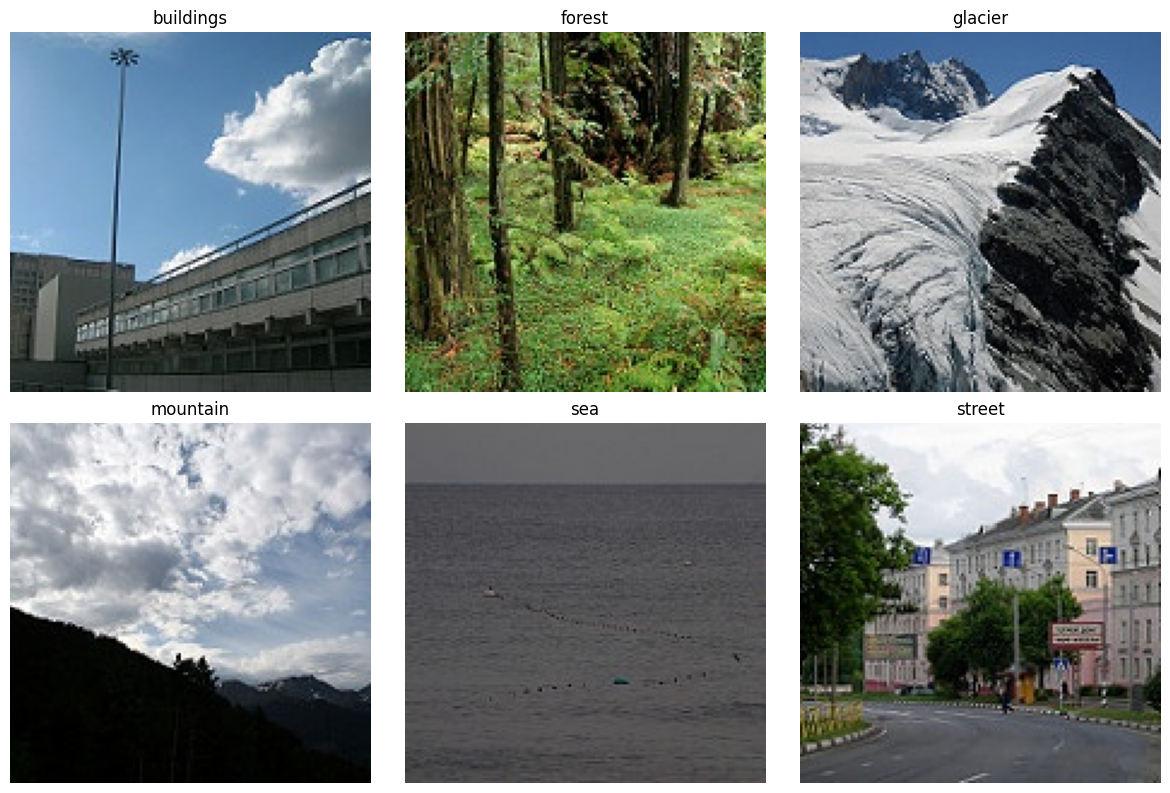

In [4]:
def load_images(n_per_class=10):
    """Load n images per class. Returns a list of (PIL.Image, label_string) tuples."""
    image_set = []
    for label in LABELS:
        class_dir = DATA_DIR / label
        # I added sorted() to make it work accross different platforms identically as I was testing this locally as well
        paths = random.sample(sorted(class_dir.glob("*.jpg")), n_per_class)
        for path in paths:
            img = Image.open(path).convert("RGB")
            image_set.append((img, label))
    random.shuffle(image_set)
    return image_set

image_set = load_images(n_per_class=10)
print(f"Total images loaded: {len(image_set)}")

# Display a 2×3 grid showing one sample image per class, labeled with the ground-truth class name. Save to outputs/dataset_sample.png.
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for ax, label in zip(axes.flatten(), LABELS):
    img = next(img for img, lbl in image_set if lbl == label)
    ax.imshow(img)
    ax.set_title(label)
    ax.axis("off")
plt.tight_layout()
plt.savefig("outputs/dataset_sample.png")
plt.show()

> Add a comment: the six scene types in this dataset are buildings, forest, glacier, mountain, sea, and street. The model you'll be using was trained on ImageNet, whose 1,000 classes include labels like "alp", "lakeside", "valley", and "barn" — not a direct match to these six categories. Does that mean a pretrained ImageNet model is a poor fit for this data, or a reasonable starting point? Why?

- A pretrained ImageNet model is a reasonable starting point for this dataset, cause the early layers of CNNs trained on large datasets (e.g. ImageNet), and they know how to detect general features such as edges, textures, and shapes that are common across many types of images.
 - Also, we can fine-tune the pretrained model on the new dataset to improved performance compared to training a model from scratch.

# Task 2: Baseline Inference with ResNet18

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 170MB/s]


ResNet18 parameters: 11,689,512
Processed 60 images.
Overall mean top-1 probability: 0.4311
Mean top-1 probability by true class:
  buildings     0.2984
  forest        0.1961
  glacier       0.7384
  mountain      0.4938
  sea           0.5506
  street        0.3092


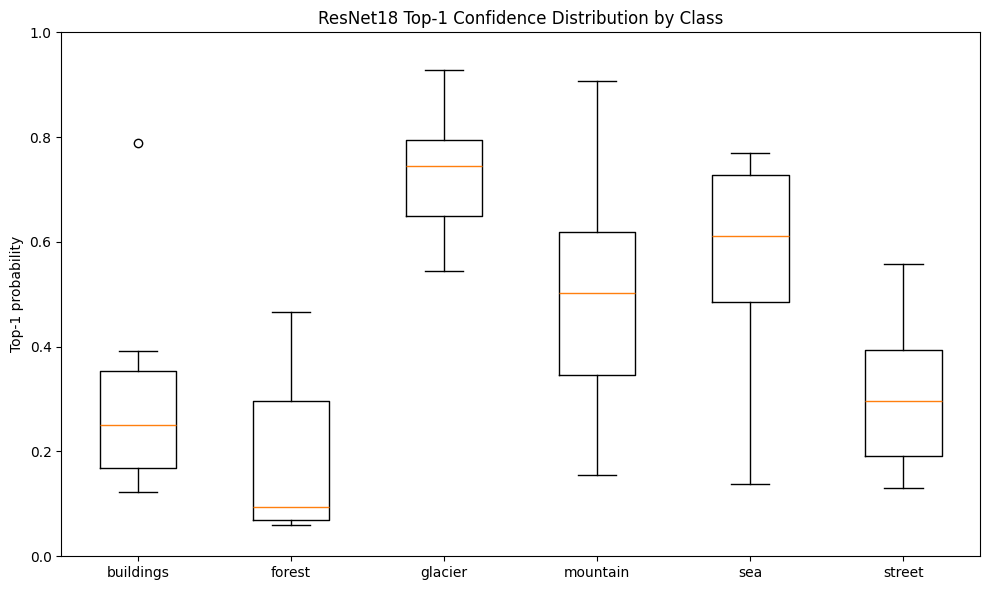

In [5]:
# Before comparing models, make sure you understand what a single model is doing end to end.

# Load ResNet18 and prepare it for inference:
resnet_weights   = ResNet18_Weights.DEFAULT
resnet           = models.resnet18(weights=resnet_weights).to(device).eval()
resnet_preproc   = resnet_weights.transforms()
imagenet_classes = resnet_weights.meta["categories"]

print(f"ResNet18 parameters: {sum(p.numel() for p in resnet.parameters()):,}")

# Write a general-purpose inference function that you will reuse for all three models. It should accept a model, a preprocessing pipeline, a PIL image, a device, a list of class labels, and an optional top_k argument. It should return a list of (class_name, probability) tuples for the top-k predictions. Name it run_inference.
def run_inference(model, preprocess, image, device, class_labels, top_k=5):
    """Run inference on a single PIL image and return top-k (class_name, probability) tuples."""
    input_tensor = preprocess(image).unsqueeze(0).to(device)
    with torch.no_grad():
        output = model(input_tensor)
    probabilities = torch.nn.functional.softmax(output[0], dim=0)
    top_probs, top_indices = torch.topk(probabilities, k=top_k)
    return [(class_labels[idx], prob.item()) for idx, prob in zip(top_indices, top_probs)]

# Run inference on every image in image_set and store the results as a list of dictionaries:
resnet_results = []
for img, true_label in image_set:
    preds = run_inference(resnet, resnet_preproc, img, device, imagenet_classes)
    resnet_results.append({
        "true_label":   true_label,
        "top1_class":   preds[0][0],
        "top1_prob":    preds[0][1],
        "top5_classes": [p[0] for p in preds],
        "top5_probs":   [p[1] for p in preds],
    })

print(f"Processed {len(resnet_results)} images.")

# Compute and print:
# Overall mean top-1 probability across all images
overall_mean_top1 = np.mean([r["top1_prob"] for r in resnet_results])
print(f"Overall mean top-1 probability: {overall_mean_top1:.4f}")

# Mean top-1 probability broken down by true class (which classes does the model feel most and least confident about?)
print("Mean top-1 probability by true class:")
mean_by_class = {}
for label in LABELS:
    class_probs = [r["top1_prob"] for r in resnet_results if r["true_label"] == label]
    mean_by_class[label] = np.mean(class_probs)
    print(f"  {label:12s}  {mean_by_class[label]:.4f}")

# Create a boxplot showing the distribution of top-1 probabilities across the six classes. Label each box with the class name, add a title, and save to outputs/resnet18_confidence_by_class.png.
probs_by_class = [[r["top1_prob"] for r in resnet_results if r["true_label"] == label] for label in LABELS]
fig, ax = plt.subplots(figsize=(10, 6))
ax.boxplot(probs_by_class)
ax.set_xticklabels(LABELS)
ax.set_ylabel("Top-1 probability")
ax.set_title("ResNet18 Top-1 Confidence Distribution by Class")
ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig("outputs/resnet18_confidence_by_class.png")
plt.show()

> Add a comment: high confidence and high accuracy are not the same thing. A model can be confidently wrong. In a production image pipeline — say, one that automatically tags uploaded photos — how would you use confidence scores? What threshold might trigger a "send to human reviewer" flag?

- In a production image tagging pipeline, I can use confidence scores to determine the reliability of the model's predictions. I can set a confidence threshold that means everything above is acceptable, and below - flagged for human review.
- For example:
    - if the model's top-1 probability is above 0.8 - the prediction reliable and automatically tag the photo;
    - if between 0.5 and 0.8 - flag it for human review to ensure accuracy;
    - if below 0.5 - reject the prediction or also flag it for review.
- The specific thresholds would depend on the desired balance between automation and accuracy, and should be tunable.


# Task 3: Multi-Model Comparison

Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 85.6MB/s]


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 137MB/s] 


ResNet18                  11,689,512 parameters
MobileNetV3-Small          2,542,856 parameters
EfficientNet-B0            5,288,548 parameters
MobileNet processed:    60 images.
EfficientNet processed: 60 images.


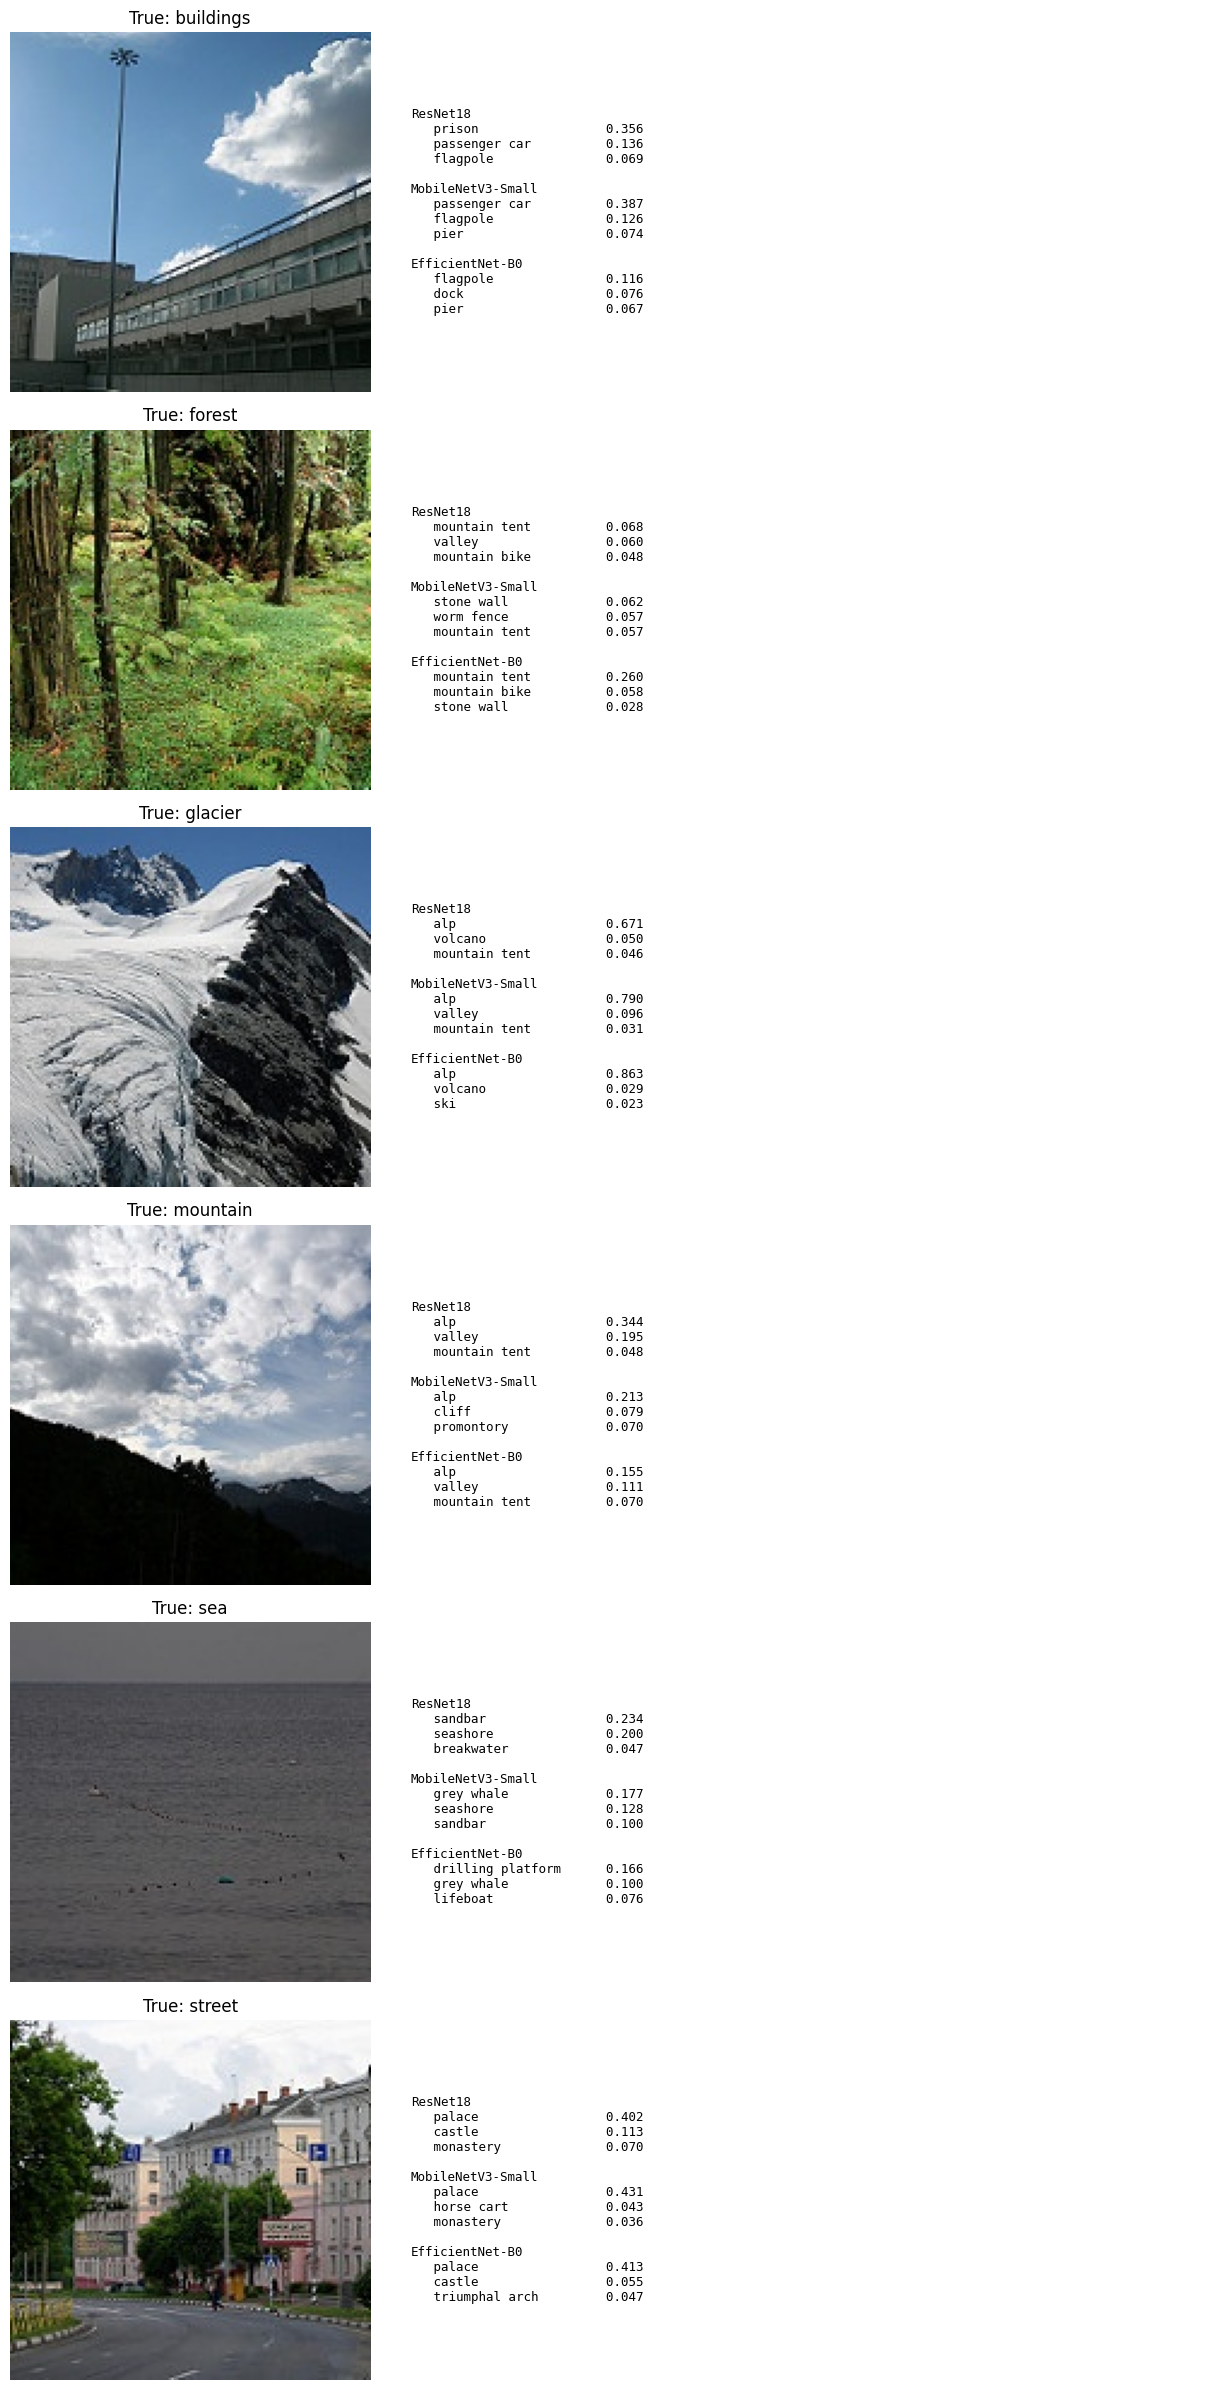

In [6]:
# Load the two additional pretrained models. Each model has its own preprocessing pipeline — using the wrong transforms will silently produce bad predictions:

# MobileNetV3-Small — designed for mobile and edge deployment
mobile_weights = MobileNet_V3_Small_Weights.DEFAULT
mobilenet      = models.mobilenet_v3_small(weights=mobile_weights).to(device).eval()
mobile_preproc = mobile_weights.transforms()

# EfficientNet-B0 — designed to maximize accuracy per unit of compute
effnet_weights = EfficientNet_B0_Weights.DEFAULT
efficientnet   = models.efficientnet_b0(weights=effnet_weights).to(device).eval()
effnet_preproc = effnet_weights.transforms()

# Print parameter counts for all three
for name, m in [("ResNet18",          resnet),
                ("MobileNetV3-Small", mobilenet),
                ("EfficientNet-B0",   efficientnet)]:
    params = sum(p.numel() for p in m.parameters())
    print(f"{name:22s}  {params:>12,} parameters")

# A smaller parameter count generally implies that a model has less capacity to learn complex patterns in the data which can end with a lower accuracy on difficult tasks.
# BUT, also it means that the model is more lightweight and usually faster, and that's great for using on something like phones.
# When deploying on a phone a smaller model like MobileNetV3-Small may be better case it is more efficient and has lower requirements (despite being less smart).
# When deploying on a cloud server (much more powerful ones) a larger model like EfficientNet-B0 may be better cause of much higher accuracy (despite being heavier).

# Run inference on the full image_set with MobileNet and EfficientNet using your run_inference function and the same dictionary structure as Task 2. Store results in mobilenet_results and effnet_results.
mobilenet_results = []
effnet_results    = []
for img, true_label in image_set:
    mobile_preds = run_inference(mobilenet, mobile_preproc, img, device, imagenet_classes)
    effnet_preds = run_inference(efficientnet, effnet_preproc, img, device, imagenet_classes)
    mobilenet_results.append({
        "true_label":   true_label,
        "top1_class":   mobile_preds[0][0],
        "top1_prob":    mobile_preds[0][1],
        "top5_classes": [p[0] for p in mobile_preds],
        "top5_probs":   [p[1] for p in mobile_preds],
    })
    effnet_results.append({
        "true_label":   true_label,
        "top1_class":   effnet_preds[0][0],
        "top1_prob":    effnet_preds[0][1],
        "top5_classes": [p[0] for p in effnet_preds],
        "top5_probs":   [p[1] for p in effnet_preds],
    })

print(f"MobileNet processed:    {len(mobilenet_results)} images.")
print(f"EfficientNet processed: {len(effnet_results)} images.")

# Build a comparison grid for 6 images — one from each class. For each image, display the image and the top-3 predictions from all three models side by side. Save to outputs/model_comparison_grid.png. The layout and implementation are up to you — clear labeling of models and classes is the main requirement.
model_results  = [("ResNet18", resnet_results),
                  ("MobileNetV3-Small", mobilenet_results),
                  ("EfficientNet-B0", effnet_results)]
sample_indices = [next(i for i, (img, lbl) in enumerate(image_set) if lbl == label) for label in LABELS]

fig, axes = plt.subplots(len(LABELS), 2, figsize=(13, 4 * len(LABELS)),
                         gridspec_kw={"width_ratios": [1, 1.6]})
for row, idx in enumerate(sample_indices):
    img, true_label = image_set[idx]
    ax_img, ax_txt  = axes[row]

    ax_img.imshow(img)
    ax_img.axis("off")
    ax_img.set_title(f"True: {true_label}")

    ax_txt.axis("off")
    blocks = []
    for model_name, results in model_results:
        r    = results[idx]
        top3 = zip(r["top5_classes"][:3], r["top5_probs"][:3])
        preds_str = "\n   ".join(f"{c:<22s} {p:.3f}" for c, p in top3)
        blocks.append(f"{model_name}\n   {preds_str}")
    ax_txt.text(0.0, 0.5, "\n\n".join(blocks),
                va="center", ha="left", fontsize=9, family="monospace")

plt.tight_layout()
plt.savefig("outputs/model_comparison_grid.png", dpi=150)
plt.show()

> After building the grid, add a comment addressing:
Do the three models generally agree on their top-1 prediction?
Are there cases where they disagree significantly? What might that tell you about whether combining model predictions (an ensemble) could help?
For this particular dataset — outdoor scenes — which model's top-5 predictions feel most semantically sensible, even when the ImageNet label isn't an exact match?

- The three models agree strongly on the distinctive natural scenes: glacier and mountain are both "alp" for all three (glacier with high confidence — 0.67 / 0.79 / 0.86), and the street image is "palace" for all three (~0.40 each, because it is a wide street lined with palatial buildings).
- They disagree most on the heavy-detailed images. The "buildings" sample is a modern glass building, and the models massed up completely with prison (ResNet) vs passenger car (MobileNet) vs flagpole (EfficientNet), all showing low-confidence. "sea" also splits - sandbar (ResNet) vs grey whale (MobileNet) vs drilling platform (EfficientNet) — tho all three stay loosely close on "sea".
- That is exactly where an ensemble could help: on the confident, agreed scenes (alp, palace) it adds little, but on the mixed answers getting an average probabilities would help a lot (e.g. EfficientNet's "drilling platform" for sea would be outvoted by the two leaning sandbar/seashore models). The caveat is that all three models are trained by ImageNet, so their errors can be similar.
- For these outdoor scenes, ResNet18 and MobileNetV3-Small feel the most semantically sensible — both recognized "alp" for mountain and glacier, and ResNet's sea guesses (sandbar / seashore / breakwater) are the most coast realated.

# Task 4: Speed vs. Accuracy Tradeoff

ResNet18:           4.10 ms/image
MobileNetV3-Small:  6.61 ms/image
EfficientNet-B0:    9.69 ms/image


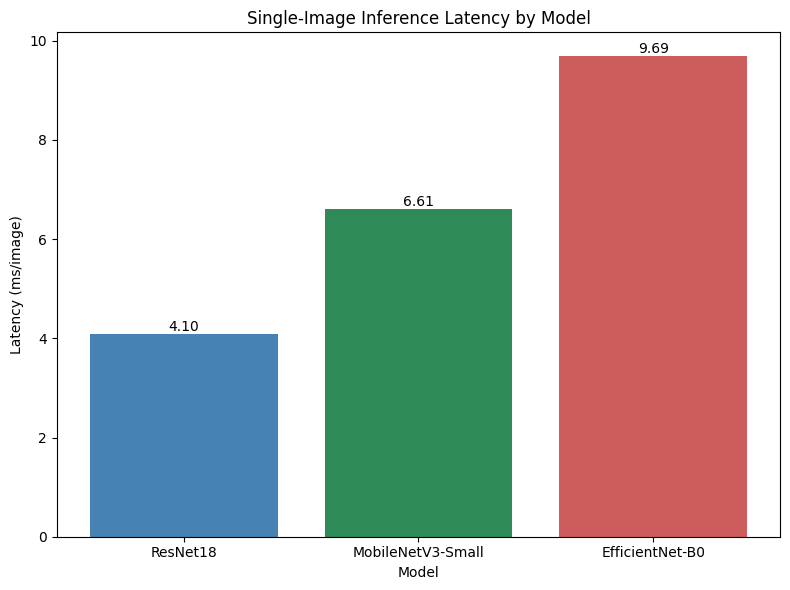

Model                      Parameters   ms / image
--------------------------------------------------
ResNet18                   11,689,512         4.10
MobileNetV3-Small           2,542,856         6.61
EfficientNet-B0             5,288,548         9.69


In [7]:
# Latency is one of the most important practical constraints when deploying a model. It determines whether a model is viable for real-time applications, batch pipelines with throughput requirements, or edge devices with limited compute.
# Benchmark all three models using the function below. Note the torch.cuda.synchronize() calls — without them, timing on a GPU is unreliable because GPU operations are asynchronous and may not have completed by the time you stop the clock:

def benchmark_model(model, preprocess, image_set, device, n_warmup=5):
    """
    Benchmark single-image inference speed.
    Returns mean latency in milliseconds per image.
    """
    # Warm up the GPU — the first few calls are slower due to CUDA initialization
    for img, _ in image_set[:n_warmup]:
        tensor = preprocess(img).unsqueeze(0).to(device)
        with torch.no_grad():
            _ = model(tensor)

    # Timed run — synchronize before and after to get accurate GPU timing
    # I added this check to be able for this notebook to be run locally on CPU where CUDA is unavailable
    if device.type == "cuda":
        torch.cuda.synchronize()
    start = time.time()

    for img, _ in image_set:
        tensor = preprocess(img).unsqueeze(0).to(device)
        with torch.no_grad():
            _ = model(tensor)

    if device.type == "cuda":
        torch.cuda.synchronize()
    elapsed = time.time() - start

    return (elapsed / len(image_set)) * 1000  # milliseconds per image

resnet_ms  = benchmark_model(resnet,       resnet_preproc,  image_set, device)
mobile_ms  = benchmark_model(mobilenet,    mobile_preproc,  image_set, device)
effnet_ms  = benchmark_model(efficientnet, effnet_preproc,  image_set, device)

print(f"ResNet18:           {resnet_ms:.2f} ms/image")
print(f"MobileNetV3-Small:  {mobile_ms:.2f} ms/image")
print(f"EfficientNet-B0:    {effnet_ms:.2f} ms/image")

# Create a bar chart showing inference latency (ms/image) for all three models. Add a title, label the axes, and save to outputs/inference_speed.png.
model_names = ["ResNet18", "MobileNetV3-Small", "EfficientNet-B0"]
latencies   = [resnet_ms, mobile_ms, effnet_ms]

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.bar(model_names, latencies, color=["steelblue", "seagreen", "indianred"])
ax.set_ylabel("Latency (ms/image)")
ax.set_xlabel("Model")
ax.set_title("Single-Image Inference Latency by Model")
for bar, ms in zip(bars, latencies):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f"{ms:.2f}", ha="center", va="bottom", fontsize=10)
plt.tight_layout()
plt.savefig("outputs/inference_speed.png")
plt.show()

# Then build a summary table comparing each model on parameters and latency:
# Model	| Parameters |	ms / image
# ResNet18	| ? |	?
# MobileNetV3-Small |	? |	?
# EfficientNet-B0	| ? | ?
models_summary = [("ResNet18",          resnet,       resnet_ms),
                  ("MobileNetV3-Small", mobilenet,    mobile_ms),
                  ("EfficientNet-B0",   efficientnet, effnet_ms)]

print(f"{'Model':22s} {'Parameters':>14s} {'ms / image':>12s}")
print("-" * 50)
for name, m, ms in models_summary:
    params = sum(p.numel() for p in m.parameters())
    print(f"{name:22s} {params:>14,} {ms:>12.2f}")

> Add a comment addressing this scenario: your team needs to classify images in near-real-time at a rate of 50 images per second. What is the maximum tolerable latency per image in milliseconds? Based on your results, which models can meet that bar?
Then add a second comment: which model would you choose if the deployment target is (a) a high-throughput cloud pipeline, (b) an on-device mobile app, (c) a safety-critical quality-control system where getting it right matters more than speed? Briefly justify each choice.

- To achieve 50 images per second, the maximum tolerable latency per image is 1000 ms / 50 = 20 ms/image. Which models meet that bar depends on the hardware: on the Kaggle GPU all three pass comfortably (ResNet18 4.10, MobileNetV3-Small 6.61, EfficientNet-B0 9.69 ms/image), but I run this locally on my laptop on CPU only, and ResNet18 makes it (9.68 ms), with MobileNetV3-Small (40.51) and EfficientNet-B0 (118.73) much bigger than 20 ms.
- (a) For a high-throughput cloud pipeline, I would choose ResNet18 because it had the lowest latency on GPU and lower than 20 ms/image latency.
- (b) For an on-device mobile app, I would choose MobileNetV3-Small because it is designed for mobile and edge hardware (the smallest model). Despite being not the fastest on a server GPU, it is built for the constrained CPUs/NPUs that phones actually use.
- (c) For a safety-critical quality-control system where getting a proper accuracy matters more than speed, I would choose EfficientNet-B0 for its higher capacity and accuracy, since latency is not the priority here.

# Task 5: Pretrained Features as a Window into Transfer Learning

Feature matrix shape: (60, 512)


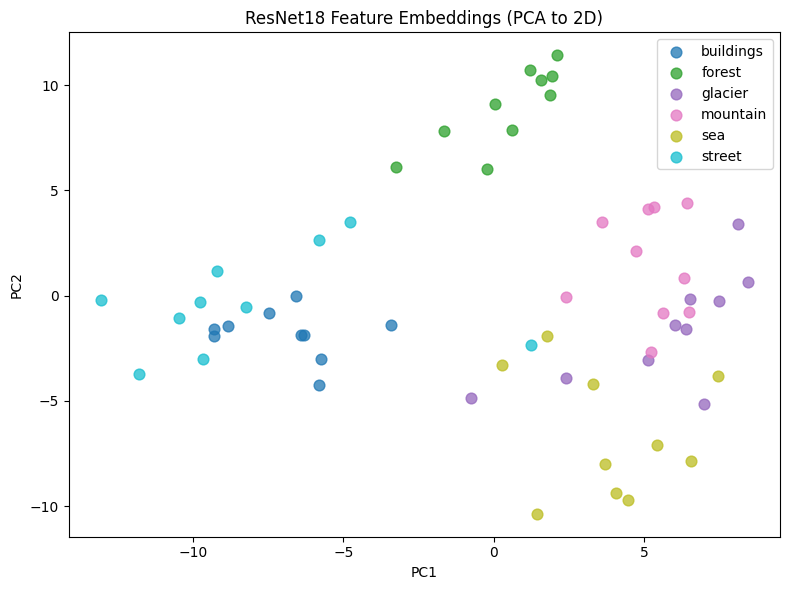

In [8]:
# One of the key ideas from the transfer learning lesson is that the early layers of a pretrained CNN learn general visual features — edges, textures, patterns — that are useful across many tasks. The final layer is the only part that is specific to ImageNet's 1,000 categories.
# This means you can use a pretrained CNN as a feature extractor: remove the final classification layer, run images through the rest of the network, and get a dense vector (an embedding) that represents the visual content of the image. This is entirely inference-based — you are not updating any weights.

# Here is how to do it with ResNet18. We replace the final fully connected layer with an identity operation, which passes the input through unchanged:

import copy

feature_extractor = copy.deepcopy(resnet)
feature_extractor.fc = torch.nn.Identity()   # remove the classification head
feature_extractor    = feature_extractor.to(device).eval()

def extract_features(model, preprocess, image, device):
    """Extract a feature vector from an image using the truncated CNN."""
    tensor   = preprocess(image).unsqueeze(0).to(device)
    with torch.no_grad():
        features = model(tensor)
    return features.squeeze().cpu().numpy()

# Extract features for all images
feature_vectors = []
true_labels     = []

for img, label in image_set:
    feat = extract_features(feature_extractor, resnet_preproc, img, device)
    feature_vectors.append(feat)
    true_labels.append(label)

feature_matrix = np.array(feature_vectors)
print(f"Feature matrix shape: {feature_matrix.shape}")
# Expected: (60, 512) — 60 images, 512-dimensional feature vector each

# Reduce the 512-dimensional feature vectors to 2D using PCA and plot them, colored by true class label:

pca          = PCA(n_components=2)
features_2d  = pca.fit_transform(feature_matrix)

fig, ax = plt.subplots(figsize=(8, 6))
colors  = plt.cm.tab10(np.linspace(0, 1, len(LABELS)))

for i, label in enumerate(LABELS):
    mask = [l == label for l in true_labels]
    ax.scatter(
        features_2d[mask, 0],
        features_2d[mask, 1],
        label=label, color=colors[i], s=60, alpha=0.75
    )

ax.legend()
ax.set_title("ResNet18 Feature Embeddings (PCA to 2D)")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
plt.tight_layout()
plt.savefig("outputs/feature_embeddings.png")
plt.show()

> Add a comment addressing:
Do images from the same class tend to cluster together in the 2D feature space? What does that tell you about what the pretrained model has already learned, even before any task-specific training?
The transfer learning lesson described two strategies: feature extraction (freeze all pretrained layers, train only a new final layer) and fine-tuning (allow some or all pretrained weights to update during training). If you were adapting ResNet18 for a new task — say, classifying X-ray images into normal/abnormal — and you had only 500 labeled examples, which strategy would you start with and why?

- Yes, images from the same class mostly cluster together in the 2D feature space. In my plot the clearest example is "forest" (green), which forms a tight, isolated cluster along the top; "sea" (yellow) sits lower and is a bit more spread. The interesting part is the overlapping "buildings" and "street" (overlap on the left), and "glacier" and "mountain" (overlap on the right).
- What this tells me is that the pretrained ResNet18 has already learned a generic reusable representation of visual content — edges, textures, shapes.
- For adapting ResNet18 to classify X-rays (normal/abnormal) with only 500 labeled examples, I would start with feature extraction (freeze all pretrained layers, train only a new final layer with X-rays images). This is cause 500 examples is too little to tune ~11 million weights, so fine-tuning won't work. Tho, X-rays are quite some different from ImageNet's dataset, so it might not work very reliable. In that case, I'd consider fine-tuning options of the last block or two (but still not the whole network).

# Task 6: Summary and Recommendation

> Write a brief summary in a markdown cell or as a comment block addressing the following. Clear technical bullets are fine — you do not need polished prose.

> Model Comparison: Based on Tasks 3 and 4, which of the three models performed best for this dataset? Reference specific observations: prediction quality, confidence scores, and speed results.

- Prediction quality: ResNet18 and MobileNetV3-Small gave the most semantically sensible predictions — all three locked onto "alp" for both glacier (high confidence, 0.67-0.86) and mountain, and agreed on "palace" for the grand-boulevard street image. They were less accurate on the harder samples: the modern-glass "buildings" image (prison / passenger car / flagpole) and "sea" (sandbar / grey whale / drilling platform). EfficientNet-B0 was a bit weaker on the ambiguous ones (drilling platform for sea, flagpole for buildings), tho it was the most confident on the easy alp cases.
- Confidence: ResNet18's overall mean top-1 was 0.43 — highest on glacier (0.74), sea (0.55), mountain (0.49); lowest on forest (0.20), buildings (0.30), street (0.31).
- Speed (GPU, single image): ResNet18 = 4.20 ms · MobileNetV3-Small = 6.90 ms · EfficientNet-B0 = 9.85 ms. Surprisingly ResNet18 is the FASTEST despite having the most parameters. I think this is cause Kaggle run it on a GPU at batch size 1 its dense convolutions parallelize better than MobileNet's depthwise-separable convolutions (param-efficient but memory-bandwidth-bound). All three are in a 50 img/s budget (20 ms/image).
- Best for this dataset: it depends on the target. On a GPU/cloud pipeline ResNet18 is the great pick: the fastest (~4 ms) with prediction quality on par with MobileNet. For an on-device/mobile target MobileNetV3-Small is better: the smallest (2.5M params) and built for edge hardware. EfficientNet-B0 is the weakest here: the slowest and the least sensible on the ambiguous scenes.

> Confidence Calibration: Looking at the boxplot from Task 2, which scene types was ResNet18 most and least confident about? Does that match your intuition about which scenes are visually distinctive?

- By per-class mean top-1, ResNet18 was MOST confident on glacier (0.74), sea (0.55), and mountain (0.49); least confident on forest (0.20), buildings (0.30), and street (0.31). Overall mean across all images was 0.43.
- This matches intuition: glacier correlates almost perfectly with ImageNet's "alp" label (the grid shows alp at 0.67-0.86 for glacier), and sea and mountain are also visually distinctive with close labels (seashore, alp). Forest has no direct ImageNet label, buildings splits its probability across many building types (palace, prison, monastery, ...), and street scenes are polluted with many objects,so all three score low.

> Production Recommendation: Your team needs to classify user-uploaded outdoor photos into six scene categories (buildings, forest, glacier, mountain, sea, street) as part of a data pipeline. Write a 3-5 sentence recommendation covering:
    Which model you would suggest starting with, and why
    What preprocessing steps the pipeline would need to include
    One limitation or risk you would flag before the team ships it

- I'd start with MobileNetV3-Small: its predictions were great (on par with ResNet18), it is by far the smallest (2.5M params), and it easily meets our latency budget (6.90 ms vs a 20 ms bar for 50 img/s). Also, despite ResNet18 was actually the fastest on GPU, MobileNet's small size makes it cheaper to serve and portable to edge.
- The pipeline must apply each model's:
    - own preprocessing (weights.transforms(): resize + center-crop to 224x224, convert to tensor, and normalize with ImageNet mean/std),
    - plus convert every upload to RGB
    - reject corrupt or non-image files before inference.
- One main risk I'd flag: these models only predict ImageNet's 1,000 classes, and not our six main categories. Thus, we should use feature extraction (as in Task 5) before this being reliable
- One more thing, cause the model is confidently wrong on ambiguous scenes (forest, buildings showed the lowest confidence), we should set a confidence threshold and route low-confidence pics to humans for reviewing.

> The goal here is not to give the "right" answer — it is to practice translating what you observed in code into a decision with reasoning behind it.


Bonus: Local CPU vs Kaggle GPU
- Same three models, single-image inference, measured on my local CPU (no CUDA) vs Kaggle's GPU:

| Model | CPU ms | GPU ms | speedup |
|---|---|---|---|
| ResNet18 | 9.68 | 4.20 | ~2.3x |
| MobileNetV3-Small | 40.51 | 6.90 | ~5.9x |
| EfficientNet-B0 | 118.73 | 9.85 | ~12x |

- The GPU helps the heaviest model the most: EfficientNet-B0 went from the slowest by far on CPU (~119 ms) to ~10 ms on GPU (~12x), while ResNet18 is already fast on CPU, it gained only ~2.3x. The GPU compresses the gap between models.
- Parameter count does not predict latency on either device: MobileNetV3-Small has the FEWEST parameters (2.5M) yet was ~4x slower than ResNet18 on CPU (40.5 vs 9.7 ms) and still slower on GPU. Its depthwise-separable convolutions are FLOP-cheap but low arithmetic intensity, so they underuse both CPU caches and GPU parallelism, while ResNet18's dense convolutions map far better onto the hardware.